# Video Game Commercial Success Prediction & Market Analysis

The goal of this project is to deliver a clear commercial narrative that game studios and publishers can use to minimize financial risk before greenlighting a new game's production.

When looking into creating new games studios and publishers investigate what has been historically successful. By analyzing characteristics of games that have already been released, we can help guide new game ideas to the right publishers to help propagate the game to a better sales pattern, allowing both the publisher and game developer to maximize their investment.

#### 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SQL alchemy
from sqlalchemy import create_engine, text

# scikitlearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
# create in-memory SQLite database
engine = create_engine('sqlite:///:memory:')

In [3]:
# load raw data
df_raw = pd.read_csv('datasets/Video_Games_Sales.csv')

In [4]:
# ingest raw data into database
df_raw.to_sql('raw_game_sales', con=engine, index=False, if_exists='replace')

16719

In [5]:
# run wuery against database to confirm ingestion
query = """
SELECT count(*)
FROM raw_game_sales
"""

In [6]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    print(f'Successfully ingested {results.scalar()} records into in-memory table "raw_game_sales".')

Successfully ingested 16719 records into in-memory table "raw_game_sales".


In [7]:
# pull data from database to pandas DataFrame
query = """
SELECT platform as platform,
    year_of_release as release_year,
    genre as genre,
    publisher as publisher,
    global_sales as global_sales
FROM raw_game_sales
WHERE global_sales IS NOT NULL
AND year_of_release IS NOT NULL
AND publisher IS NOT NULL;
"""

In [8]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    df_pulled = pd.DataFrame(results)

In [9]:
df_pulled.info()

<class 'pandas.DataFrame'>
RangeIndex: 16418 entries, 0 to 16417
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   platform      16418 non-null  str    
 1   release_year  16418 non-null  float64
 2   genre         16416 non-null  str    
 3   publisher     16418 non-null  str    
 4   global_sales  16418 non-null  float64
dtypes: float64(2), str(3)
memory usage: 641.5 KB


#### 2. Data Cleaning & Target Creation

In [10]:
# drop missing values
df_clean = df_pulled.dropna(subset='genre').copy()

In [11]:
# parse release_year to 'int' from 'float64'
df_clean['release_year'] = df_clean['release_year'].astype(int)

##### Create Dynamic Target

In [12]:
# top 20% global sales within each release year
df_clean['year_80th_p'] = df_clean.groupby('release_year')['global_sales'].transform(lambda x: x.quantile(0.80))
df_clean['is_hit'] = (df_clean['global_sales'] >= df_clean['year_80th_p']).astype(int)

In [13]:
# reduction of publisher cardinality
top_publishers = df_clean['publisher'].value_counts().nlargest(15).index
df_clean['publisher_grouped'] = df_clean['publisher'].apply(lambda x: x if x in top_publishers else 'Other')

In [14]:
# get top platforms
nin = 'nintendo'
pl = 'playstation'
xb = 'xbox'
platform_map = {
    'PS': pl, 'PS2': pl, 'PS2': pl, 'PS3': pl, 'PS4': pl, 'PSP': pl, 'PSV': pl,
    'XB': xb, 'X360': xb, 'XOne': xb,
    'Wii': nin, 'WiiU': nin, 'DS': nin, '3DS': nin, 'GBA': nin, 'GB': nin, 'GC': nin, 'N64': nin
}

df_clean['platform_family'] = df_clean['platform'].map(platform_map).fillna('Other')

In [15]:
print(f'Cleaned dataset shape: {df_clean.shape}')
print(f'Target Distribution (is_hit): \n', df_clean['is_hit'].value_counts(normalize=True))

Cleaned dataset shape: (16416, 9)
Target Distribution (is_hit): 
 is_hit
0    0.797636
1    0.202364
Name: proportion, dtype: float64


#### 3. Feature Selection & Train/Test Split

In [16]:
# Strictly pre-release features to prevent target leakage
features = ['platform_family', 'genre', 'publisher_grouped', 'release_year']

In [17]:
# temporal time split
cutoff_year = 2013

train_mask = df_clean['release_year'] < cutoff_year
test_mask = df_clean['release_year'] >= cutoff_year

X_train = df_clean.loc[train_mask, features]
y_train = df_clean.loc[train_mask, 'is_hit']

X_test = df_clean.loc[test_mask, features]
y_test = df_clean.loc[test_mask, 'is_hit']


#### 4. Preprocessing & Model Pipline

In [18]:
categorical_features = ['platform_family', 'genre', 'publisher_grouped']
numeric_features = ['release_year']

In [19]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)
    ]
)

In [20]:
pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators = 300 ,random_state = 42, class_weight='balanced'))
])

In [21]:
# fit model on training set
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['platform_family','genre','publisher_grouped','release_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

#### 5. Evaluation

In [22]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

custom_threshold = .3754

y_pred_custom = (y_proba >= custom_threshold).astype(int)

In [23]:
print('--- Model Evaluation ---')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'\nClassification report:\n', classification_report(y_test, y_pred_custom))

--- Model Evaluation ---
ROC-AUC: 0.7698

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.65      0.77      1779
           1       0.38      0.83      0.52       456

    accuracy                           0.69      2235
   macro avg       0.66      0.74      0.64      2235
weighted avg       0.82      0.69      0.72      2235



In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred_custom)
prec = precision_score(y_test, y_pred_custom)
rec = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)

In [25]:
print('--- Model Performance Metrics ---')
print(f'Accuracy: {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1-Score: {f1:.4f}')

--- Model Performance Metrics ---
Accuracy: 0.6859
Precision: 0.3775
Recall: 0.8311
F1-Score: 0.5192


In [26]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get predicted probabilities
y_scores = pipeline.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Find threshold that maximizes F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")

Optimal Threshold: 0.3754
Best F1-Score: 0.5192


Text(145.38563368055554, 0.5, 'Actual Class')

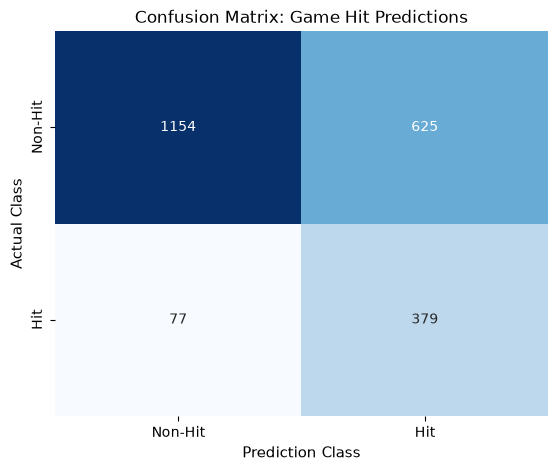

In [27]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Non-Hit', 'Hit'],
    yticklabels=['Non-Hit', 'Hit']
)

plt.title('Confusion Matrix: Game Hit Predictions')
plt.xlabel('Prediction Class', fontsize=11)
plt.ylabel('Actual Class', fontsize=11)